# MasterClass_AI for Document Understanding
## B1: Tổng quan về Document Understanding

### 1.Import thư viện PaddleOCR

In [ ]:
!nvidia-smi

Wed Jul  8 14:24:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Cài PaddlePaddle-GPU (khớp CUDA 13.0 của Colab)
# !python -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!python -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/
# Cài PaddleOCR
!pip install pymupdf
!python -m pip install -U paddleocr

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu130/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 395.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.9/420.9 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Kiểm tra cài thành công chưa?
import paddle
print("PaddlePaddle version:", paddle.__version__)
print("GPU available:", paddle.device.is_compiled_with_cuda())

import paddlex
print("paddlex version:", paddlex.__version__)

import paddleocr
print("PaddleOCR version:", paddleocr.__version__)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


PaddlePaddle version: 3.3.0
GPU available: True
paddlex version: 3.7.2
PaddleOCR version: 3.7.0


In [ ]:
!python -m pip install "paddlex[ocr]==3.7.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 21.2 MB/s eta 0:00:00


### 2. Data

In [ ]:
# Code hiển thị ảnh
import matplotlib.pyplot as plt
from PIL import Image

def show_image(path_or_img, figsize=(5, 7), title=None):
    img = Image.open(path_or_img) if isinstance(path_or_img, str) else path_or_img
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

Downloading...
From: https://drive.google.com/uc?id=1895KZNAQLkyk5K6nPsitEsVlwBa42A25
To: /content/highlands_receipt.png
100%|██████████| 1.57M/1.57M [00:00<00:00, 200MB/s]


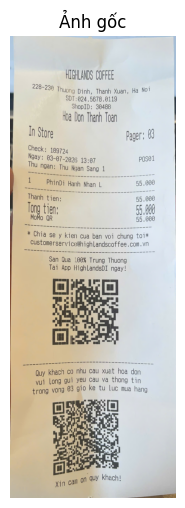

In [ ]:
!pip install -q gdown

import gdown
file_id = "1895KZNAQLkyk5K6nPsitEsVlwBa42A25"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "highlands_receipt.png", quiet=False)

show_image("highlands_receipt.png", figsize=(4, 6), title="Ảnh gốc")

### 3. PP-OCRv5 / PP-OCRv6


In [ ]:
from paddleocr import PaddleOCR

# ocr_v6 = PaddleOCR(
#     text_detection_model_name="PP-OCRv6_medium_det",
#     text_recognition_model_name="PP-OCRv6_medium_rec",
#     use_doc_orientation_classify=True,  # tự xoay lại nếu ảnh chụp ngược/lệch
#     use_doc_unwarping=True,             # làm phẳng ảnh nếu giấy bị cong/nhăn
#     use_textline_orientation=True,      # xử lý dòng chữ bị nghiêng cục bộ
# )

ocr_v6 = PaddleOCR(
    # --- Model ---
    text_detection_model_name="PP-OCRv6_medium_det",
    text_recognition_model_name="PP-OCRv6_medium_rec",

    # --- Preprocessing ---
    use_doc_orientation_classify=True,   # tự xoay lại nếu ảnh chụp ngược/lệch
    use_doc_unwarping=True,              # làm phẳng ảnh nếu giấy bị cong/nhăn
    use_textline_orientation=True,       # xử lý dòng chữ bị nghiêng cục bộ

    # --- Detection: chỉnh khi ảnh khó (bị sót/thừa box) ---
    text_det_thresh=0.3,                 # ngưỡng nhạy phát hiện pixel chữ — giảm nếu bị BỎ SÓT text
    text_det_box_thresh=0.6,             # ngưỡng giữ lại box — giảm nếu box bị thiếu
    text_det_unclip_ratio=1.5,           # độ nới rộng box quanh chữ — tăng nếu box cắt sát chữ

    # --- Recognition: lọc kết quả rác ---
    text_rec_score_thresh=0.0,           # bỏ text có confidence dưới ngưỡng này (vd 0.5 để lọc rác)
    lang="vi",

    # --- Thiết bị ---
    device="gpu:0",
)

result = ocr_v6.predict("highlands_receipt.png")

for res in result:
    res.print()
    res.save_to_img("output_v6")
    res.save_to_json("output_v6")

result = ocr_v6.predict("highlands_receipt.png")

for res in result:
    res.print()
    res.save_to_img("output_v6")     # ảnh có vẽ box + text
    res.save_to_json("output_v6")    # kết quả dạng JSON

/tmp/ipykernel_1139/2205686621.py:11: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr_v6 = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('

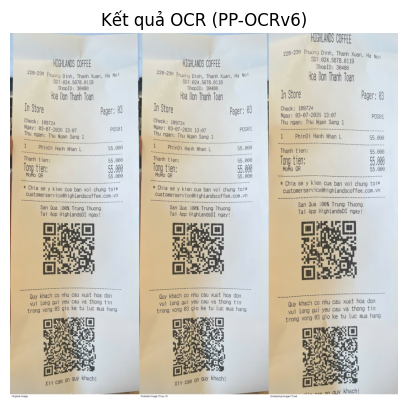

In [ ]:
import glob
result_img = glob.glob("output_v6/*.png") or glob.glob("output_v6/*.jpg")
show_image(result_img[0], figsize=(5, 8), title="Kết quả OCR (PP-OCRv6)")

In [ ]:
import pandas as pd

rows = []
for res in result:
    for box, text, score in zip(res['dt_polys'], res['rec_texts'], res['rec_scores']):
        rows.append({
            "text": text,
            "score": round(float(score), 3),
            "x_min": box[:, 0].min(), "y_min": box[:, 1].min(),
            "x_max": box[:, 0].max(), "y_max": box[:, 1].max(),
        })

df = pd.DataFrame(rows)
df

,text,score,x_min,y_min,x_max,y_max
0,HIGHLANDS COFFEE,0.972,274,0,557,79
1,SDT:024.5678.0119,1.000,276,149,569,206
2,ShopID: 30488,0.986,308,197,538,252
3,Hoa Don Thanh Toan,0.997,257,241,575,333
4,In Store,1.000,70,360,223,447
5,Pager: 03,0.988,603,367,773,458
6,Check: 189724,0.989,75,475,300,521
7,Ngay: 03-07-2026 13:07,0.999,75,518,451,567
8,P0S01,0.925,676,527,768,576
9,Thu ngan: Thu Ngan Sang 1,0.999,76,568,500,612


### 4. PP-StructureV3

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from paddleocr import PPStructureV3

structure_pipeline = PPStructureV3(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device="gpu:0",
)

output = structure_pipeline.predict("highlands_receipt.png")

for res in output:
    res.print()                              # in cấu trúc layout ra console
    res.save_to_img("output_structure")      # ảnh vẽ box theo từng loại vùng (title/text/table...)
    res.save_to_json("output_structure")     # JSON có cấu trúc phân cấp
    res.save_to_markdown("output_structure") # xuất luôn ra Markdown — rất tiện để đưa vào LLM/RAG

Creating model: ('PP-DocBlockLayout', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-DocBlockLayout), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocBlockLayout`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-DocLayout_plus-L', None, None)
Using official model (PP-DocLayout_plus-L), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocLayout_plus-L`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


...

Creating model: ('RT-DETR-L_wireless_table_cell_det', None, None)
Using official model (RT-DETR-L_wireless_table_cell_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/RT-DETR-L_wireless_table_cell_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-FormulaNet_plus-L', None, None)
Using official model (PP-FormulaNet_plus-L), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-FormulaNet_plus-L`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: 'highlands_receipt.png'

Các file ảnh tìm được:
 - output_structure/highlands_receipt_preprocessed_img.png
 - output_structure/highlands_receipt_layout_order_res.png
 - output_structure/highlands_receipt_layout_det_res.png
 - output_structure/highlands_receipt_region_det_res.png
 - output_structure/highlands_receipt_overall_ocr_res.png
 - output_structure/imgs/img_in_image_box_213_1238_583_1635.jpg
 - output_structure/imgs/img_in_image_box_221_1938_596_2345.jpg


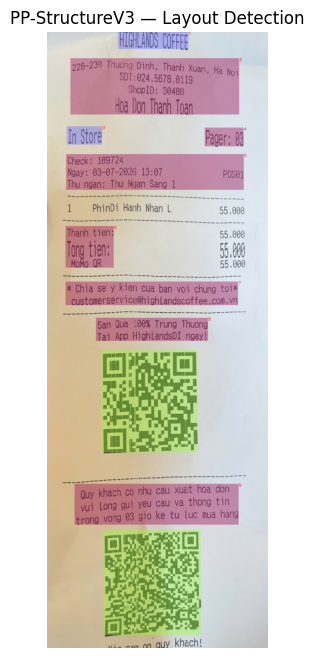

In [ ]:
import glob

# Tìm tất cả ảnh trong output_structure (kể cả trong subfolder con)
all_imgs = glob.glob("output_structure/**/*.png", recursive=True) + glob.glob("output_structure/**/*.jpg", recursive=True)

print("Các file ảnh tìm được:")
for p in all_imgs:
    print(" -", p)

# Lọc đúng ảnh layout detection (có box + màu theo từng loại vùng)
layout_img = [p for p in all_imgs if "layout" in p.lower()]

if layout_img:
    show_image(layout_img[0], figsize=(5, 8), title="PP-StructureV3 — Layout Detection")
else:
    print("\nKhông thấy ảnh có chữ 'layout' trong tên — xem danh sách phía trên để chọn đúng file")

In [ ]:
import pandas as pd

rows = []
for res in output:
    for block in res['parsing_res_list']:
        d = block.to_dict()
        rows.append({
            "order": d.get("order_index", d.get("index")),
            "label": d.get("label"),
            "content": d.get("content"),
            "bbox": [round(float(c), 1) for c in d.get("bbox", [])],
        })

df_structure = pd.DataFrame(rows).sort_values("order", na_position="last").reset_index(drop=True)
df_structure

,order,label,content,bbox
0,1.0,paragraph_title,HIGHLANDS COFFEE,"[276.0, 0.0, 548.0, 65.0]"
1,2.0,text,22SDT:024.5678.0119ShopID:30488Hoa Don Thanh T...,"[91.0, 102.0, 745.0, 320.0]"
2,3.0,paragraph_title,In Store,"[77.0, 367.0, 213.0, 437.0]"
3,4.0,text,Pager:03,"[612.0, 372.0, 762.0, 444.0]"
4,5.0,text,Check:189724\n\nNgay: 03-07-202613:07POS01\nTh...,"[74.0, 475.0, 763.0, 613.0]"
5,6.0,text,Thanh tien:Tong tien:MOMo QR,"[72.0, 755.0, 258.0, 916.0]"
6,7.0,text,* Chia se y kien cua ban voi chung toi*custome...,"[72.0, 971.0, 741.0, 1062.0]"
7,8.0,text,San Qua 100% Trung Thuong Tai App HighlandsDI ...,"[190.0, 1112.0, 624.0, 1201.0]"
8,9.0,text,Quy khach co nhu cau xuat hoa don vui Long gui...,"[107.0, 1758.0, 743.0, 1916.0]"
9,NaN,image,,"[213.0, 1238.0, 583.0, 1635.0]"
